In [3]:

!pip install langdetect textblob deep-translator wordcloud nltk scikit-learn

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


ORIGINAL TEXT

Artificial Intelligence is transforming the world.
It helps automate tasks and improve productivity.
Many industries use AI for better decision making.
AI is also helping healthcare, education and business.


Detected Language: en

Sentiment: Positive
Polarity Score: 0.133

SUMMARY:

Artificial Intelligence is transforming the world. 
It helps automate tasks and improve productivity

TELUGU TRANSLATION:
ఆర్టిఫిషియల్ ఇంటెలిజెన్స్ ప్రపంచాన్ని మార్చేస్తోంది.
ఇది పనులను ఆటోమేట్ చేయడానికి మరియు ఉత్పాదకతను మెరుగుపరచడంలో సహాయపడుతుంది.
అనేక పరిశ్రమలు మెరుగైన నిర్ణయం తీసుకోవడానికి AIని ఉపయోగిస్తాయి.
AI ఆరోగ్య సంరక్షణ, విద్య మరియు వ్యాపారానికి కూడా సహాయం చేస్తోంది.

TOP KEYWORDS:
['ai', 'artificial', 'automate', 'better', 'business', 'decision', 'education', 'healthcare', 'helping', 'helps']

RESULTS TABLE
     Feature    Result
0   Language        en
1  Sentiment  Positive
2   Polarity  0.133333


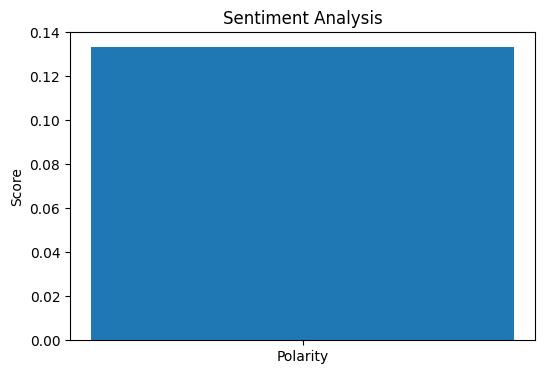

In [5]:
# ==========================================
# NLP PROJECT: TEXT ANALYZER + TRANSLATOR
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
from langdetect import detect
from textblob import TextBlob
from deep_translator import GoogleTranslator
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import nltk

nltk.download('punkt')

# ==========================================
# INPUT TEXT
# ==========================================

text = """
Artificial Intelligence is transforming the world.
It helps automate tasks and improve productivity.
Many industries use AI for better decision making.
AI is also helping healthcare, education and business.
"""

print("="*50)
print("ORIGINAL TEXT")
print("="*50)
print(text)

# ==========================================
# LANGUAGE DETECTION
# ==========================================

language = detect(text)

print("\nDetected Language:", language)

# ==========================================
# SENTIMENT ANALYSIS
# ==========================================

blob = TextBlob(text)

polarity = blob.sentiment.polarity

if polarity > 0:
    sentiment = "Positive"
elif polarity < 0:
    sentiment = "Negative"
else:
    sentiment = "Neutral"

print("\nSentiment:", sentiment)
print("Polarity Score:", round(polarity, 3))

# ==========================================
# TEXT SUMMARIZATION
# ==========================================

sentences = text.split('.')

summary = '. '.join(sentences[:2])

print("\nSUMMARY:")
print(summary)

# ==========================================
# TRANSLATION
# ==========================================

translated_text = GoogleTranslator(
    source='auto',
    target='te'   # te=Telugu
).translate(text)

print("\nTELUGU TRANSLATION:")
print(translated_text)

# ==========================================
# KEYWORD EXTRACTION
# ==========================================

vectorizer = CountVectorizer(
    stop_words='english',
    max_features=10
)

X = vectorizer.fit_transform([text])

keywords = vectorizer.get_feature_names_out()

print("\nTOP KEYWORDS:")
print(list(keywords))

# ==========================================
# RESULTS TABLE
# ==========================================

results = pd.DataFrame({
    "Feature": [
        "Language",
        "Sentiment",
        "Polarity"
    ],
    "Result": [
        language,
        sentiment,
        polarity
    ]
})

print("\nRESULTS TABLE")
print(results)

# ==========================================
# SENTIMENT CHART
# ==========================================

plt.figure(figsize=(6,4))
plt.bar(["Polarity"], [polarity])
plt.title("Sentiment Analysis")
plt.ylabel("Score")
plt.show()

